In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

BASE_DIR = os.path.join('..')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

# 1. Charger les memes donnees, meme split que pour l'entrainement
df = pd.read_csv('../data/processed/shots_features.csv')
target_column = 'is_goal'   
X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Reentrainer le meme Random Forest tune (memes hyperparametres que train_rf.py)
model = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_leaf=10,
    random_state=42, class_weight='balanced'
)
model.fit(X_train, y_train)

# 3. Calculer les valeurs SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print("Shape :", shap_values.shape)

Shape : (286, 23, 2)


In [2]:
# Summary plot (vue globale), classe "but" = 1
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'shap_summary_plot.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Summary plot sauvegarde.")

# Waterfall plot (un tir precis, index 0), classe "but" = 1
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'shap_waterfall_example.png'), dpi=150, bbox_inches='tight')
plt.close()
print("Waterfall plot sauvegarde.")

Summary plot sauvegarde.
Waterfall plot sauvegarde.


In [3]:
import pandas as pd

df = pd.read_csv('../data/processed/shots_features.csv')

print(df.shape)
print(df.dtypes)
df.head()

(1430, 24)
is_goal                               int64
distance_to_goal                    float64
shot_angle                          float64
defenders_in_cone                     int64
distance_to_keeper                  float64
under_pressure                        int64
shot_first_time                       int64
body_part_name_Left Foot               bool
body_part_name_Other                   bool
body_part_name_Right Foot              bool
technique_name_Diving Header           bool
technique_name_Half Volley             bool
technique_name_Lob                     bool
technique_name_Normal                  bool
technique_name_Overhead Kick           bool
technique_name_Volley                  bool
play_pattern_name_From Counter         bool
play_pattern_name_From Free Kick       bool
play_pattern_name_From Goal Kick       bool
play_pattern_name_From Keeper          bool
play_pattern_name_From Kick Off        bool
play_pattern_name_From Throw In        bool
play_pattern_name_Oth

,is_goal,distance_to_goal,shot_angle,defenders_in_cone,distance_to_keeper,under_pressure,shot_first_time,body_part_name_Left Foot,body_part_name_Other,body_part_name_Right Foot,...,technique_name_Overhead Kick,technique_name_Volley,play_pattern_name_From Counter,play_pattern_name_From Free Kick,play_pattern_name_From Goal Kick,play_pattern_name_From Keeper,play_pattern_name_From Kick Off,play_pattern_name_From Throw In,play_pattern_name_Other,play_pattern_name_Regular Play
0,0,23.510423,0.336909,2,22.058105,1,1,True,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,36.444616,0.216633,1,13.418271,0,1,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0,33.238532,0.239265,3,32.330326,0,0,False,False,True,...,False,False,False,True,False,False,False,False,False,False
3,0,15.423683,0.438296,3,13.464769,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,8.420214,0.773417,0,4.110961,0,1,False,False,True,...,False,False,True,False,False,False,False,False,False,False


is_goal
0    1278
1     152
Name: count, dtype: int64

Taux de but : 10.6%


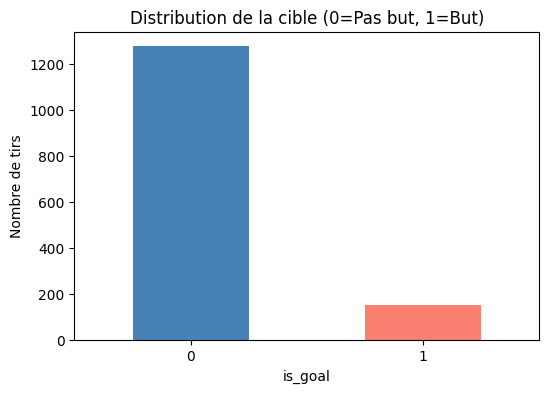

In [4]:
import matplotlib.pyplot as plt

target_counts = df['is_goal'].value_counts()
print(target_counts)
print(f"\nTaux de but : {target_counts[1] / len(df) * 100:.1f}%")

plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribution de la cible (0=Pas but, 1=But)')
plt.xlabel('is_goal')
plt.ylabel('Nombre de tirs')
plt.xticks(rotation=0)
plt.show()

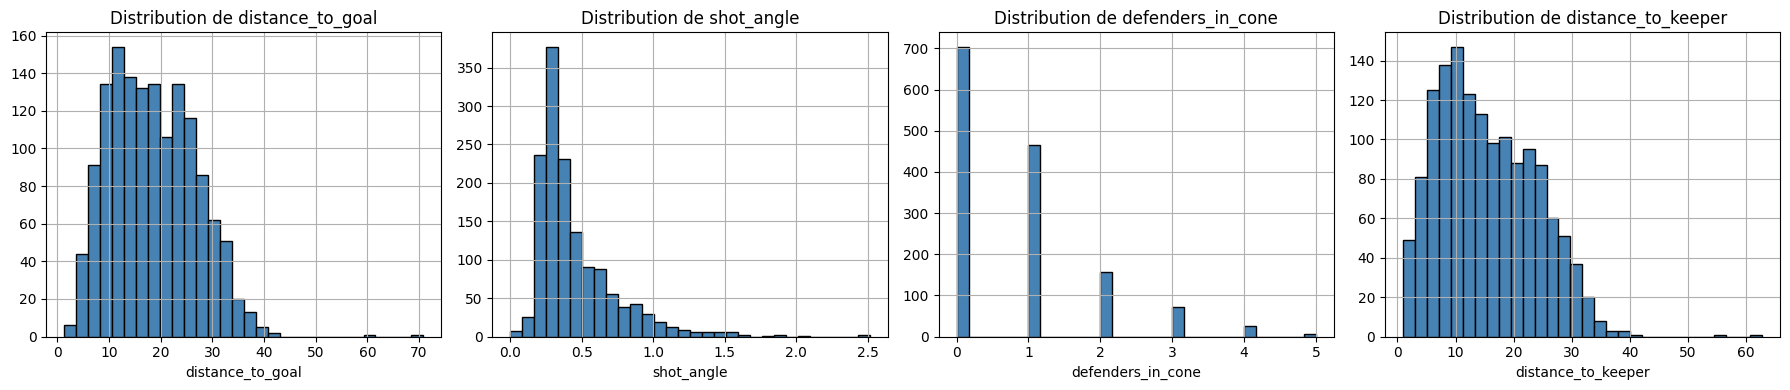

       distance_to_goal   shot_angle  defenders_in_cone  distance_to_keeper
count       1430.000000  1430.000000        1430.000000         1430.000000
mean          18.457459     0.453111           0.790210           15.400615
std            8.208777     0.282731           0.996517            8.400918
min            1.315295     0.000000           0.000000            0.921954
25%           11.907873     0.269570           0.000000            8.522609
50%           17.809267     0.351441           1.000000           14.276367
75%           24.479328     0.551464           1.000000           21.743159
max           70.830784     2.511797           5.000000           62.830088


In [5]:
numeric_cols = ['distance_to_goal', 'shot_angle', 'defenders_in_cone', 'distance_to_keeper']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

print(df[numeric_cols].describe())

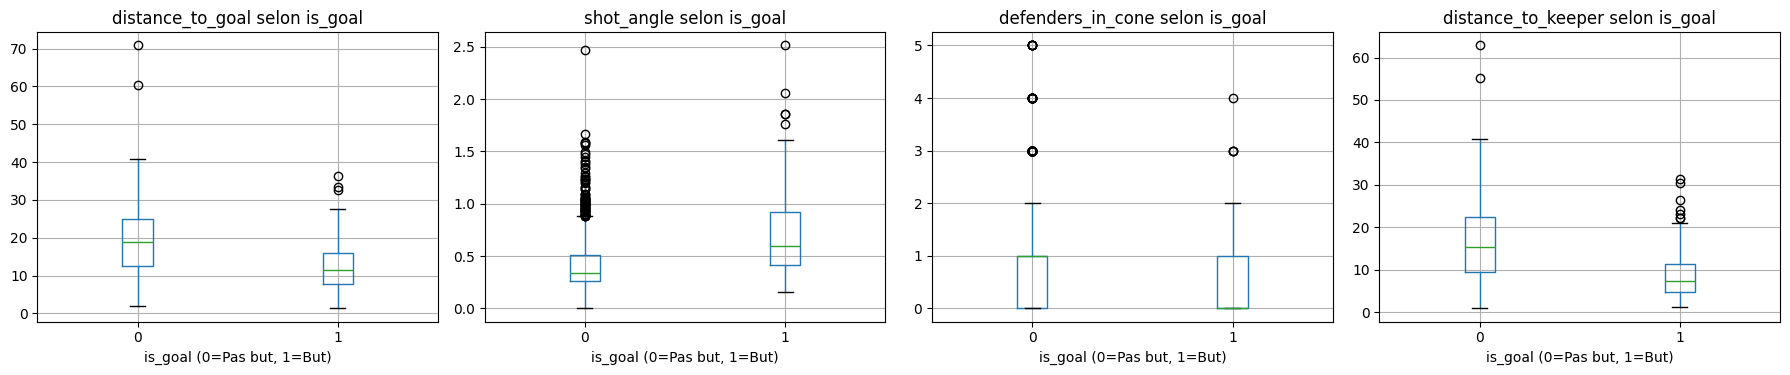

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='is_goal', ax=axes[i])
    axes[i].set_title(f'{col} selon is_goal')
    axes[i].set_xlabel('is_goal (0=Pas but, 1=But)')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [7]:
correlations = df.corr()['is_goal'].sort_values(key=abs, ascending=False)
print("--- Correlations avec la Cible (is_goal) ---")
print(correlations)

--- Correlations avec la Cible (is_goal) ---
is_goal                             1.000000
shot_angle                          0.311424
distance_to_keeper                 -0.269358
distance_to_goal                   -0.257151
defenders_in_cone                  -0.150577
shot_first_time                     0.102776
technique_name_Lob                  0.086493
play_pattern_name_From Goal Kick    0.064138
play_pattern_name_From Counter      0.047343
technique_name_Volley               0.039034
body_part_name_Other                0.038683
body_part_name_Right Foot          -0.035436
play_pattern_name_From Throw In    -0.031705
technique_name_Normal              -0.029444
body_part_name_Left Foot            0.024566
technique_name_Overhead Kick       -0.024188
play_pattern_name_Other            -0.018265
play_pattern_name_Regular Play      0.017597
technique_name_Diving Header       -0.011248
under_pressure                     -0.007906
play_pattern_name_From Free Kick   -0.007348
play_patte